# 🧬 Project: Bacterial Single-Cell RNA-Seq Analysis (microSPLiT)
## 📓 Notebook 01: Data Loading, AnnData Construction & Quality Control

### 📌 Overview
In this notebook, we begin the downstream analysis of single-cell RNA-seq data from *Bacillus subtilis* (Dataset: **GSE151940**), generated using the **microSPLiT** technique. We will focus on the main growth-course experiment (`GSM4594095`) tracking bacterial cells across 10 different Optical Densities (OD0.5 to OD6.0).

### 🎯 Objectives for this step:
1. Load the raw count matrix, gene names, and cell metadata using `Pandas`.
2. Construct a unified `AnnData` object compatible with `Scanpy`.
3. Calculate Quality Control (QC) metrics specific to bacterial cells and perform initial filtering.

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [6]:
# Load cell metadata WITH header=None so we don't lose the first cell
metadata = pd.read_csv('data/GSM4594095_mRNA_M14_ODannotation.csv.gz', header=None, names=['OD_stage'])
print(f"Metadata shape: {metadata.shape}")

Metadata shape: (25446, 1)


In [5]:
# Load the main expression matrix
# It is ALREADY in (Cells x Genes) format, so NO NEED for .T
counts = pd.read_csv('data/GSM4594095_mRNA_M14_200.csv.gz', header=None)
print(f"Counts Matrix shape (cells x genes): {counts.shape}")

Counts Matrix shape (cells x genes): (25446, 3769)


### 🏗️ Step 2: Constructing the AnnData Object

`Scanpy` relies on the `AnnData` (Annotated Data) object to store single-cell datasets. It acts as a unified container mapping three main components:
* **`X`**: The core expression matrix (cells $\times$ genes).
* **`obs` (Observations)**: A dataframe storing cell-level metadata (e.g., OD stages).
* **`var` (Variables)**: A dataframe storing gene-level metadata (e.g., gene symbols).

Here, we instantiate the `AnnData` object, align our metadata, and assign unique identifiers (barcodes) to our bacterial cells.

In [7]:
# 1. Initialize the AnnData object with the count matrix
adata = sc.AnnData(X=counts.values)

# 2. Add cell metadata to the .obs (Observations) attribute
adata.obs['OD_stage'] = metadata['OD_stage'].values

# 3. Add gene names to the .var (Variables) attribute and set them as index
adata.var_names = genes['gene_symbols'].values
adata.var['gene_name'] = genes['gene_symbols'].values

# 4. Generate unique names (barcodes) for the cells
adata.obs_names = [f"cell_{i}" for i in range(adata.n_obs)]

# 5. Make gene names unique (in case there are duplicates in the raw data)
adata.var_names_make_unique()

# Print the final object to see its structure
print(adata)

AnnData object with n_obs × n_vars = 25446 × 3769
    obs: 'OD_stage'
    var: 'gene_name'


### 💾 Step 3: Saving the AnnData Object to Disk

Currently, the `AnnData` object exists only in memory (RAM). To avoid reprocessing the raw text files in the future, we will save this structured object to disk as an `.h5ad` file. This format is highly optimized for single-cell data and can be easily loaded into any Python environment.

In [8]:
# Define the path and filename for our new dataset
output_file = 'data/bacterial_microSPLiT_raw.h5ad'

# Save the AnnData object
adata.write(output_file)

print(f"✅ Success! The AnnData object is securely saved to: {output_file}")

✅ Success! The AnnData object is securely saved to: data/bacterial_microSPLiT_raw.h5ad


### 🔬 Step 4: Quality Control (QC) Metrics

Before proceeding with dimensionality reduction and clustering, we must filter out low-quality cells and artifacts (e.g., empty droplets or doublets). 
Unlike eukaryotic cells, bacteria lack mitochondria, so we do not filter based on mitochondrial gene fractions. Instead, our QC relies on:
1. **`n_genes_by_counts`**: The number of genes expressed per cell. Cells with extremely low counts are typically ambient RNA or empty droplets.
2. **`total_counts`**: The total number of transcripts (UMIs) per cell. Extremely high counts often indicate doublets (two cells captured together).

Let's calculate these metrics and visualize their distribution using violin plots.

/home/azureuser/miniconda3/envs/bacterial_sc_env/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:428: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]


New QC columns added: ['OD_stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes']


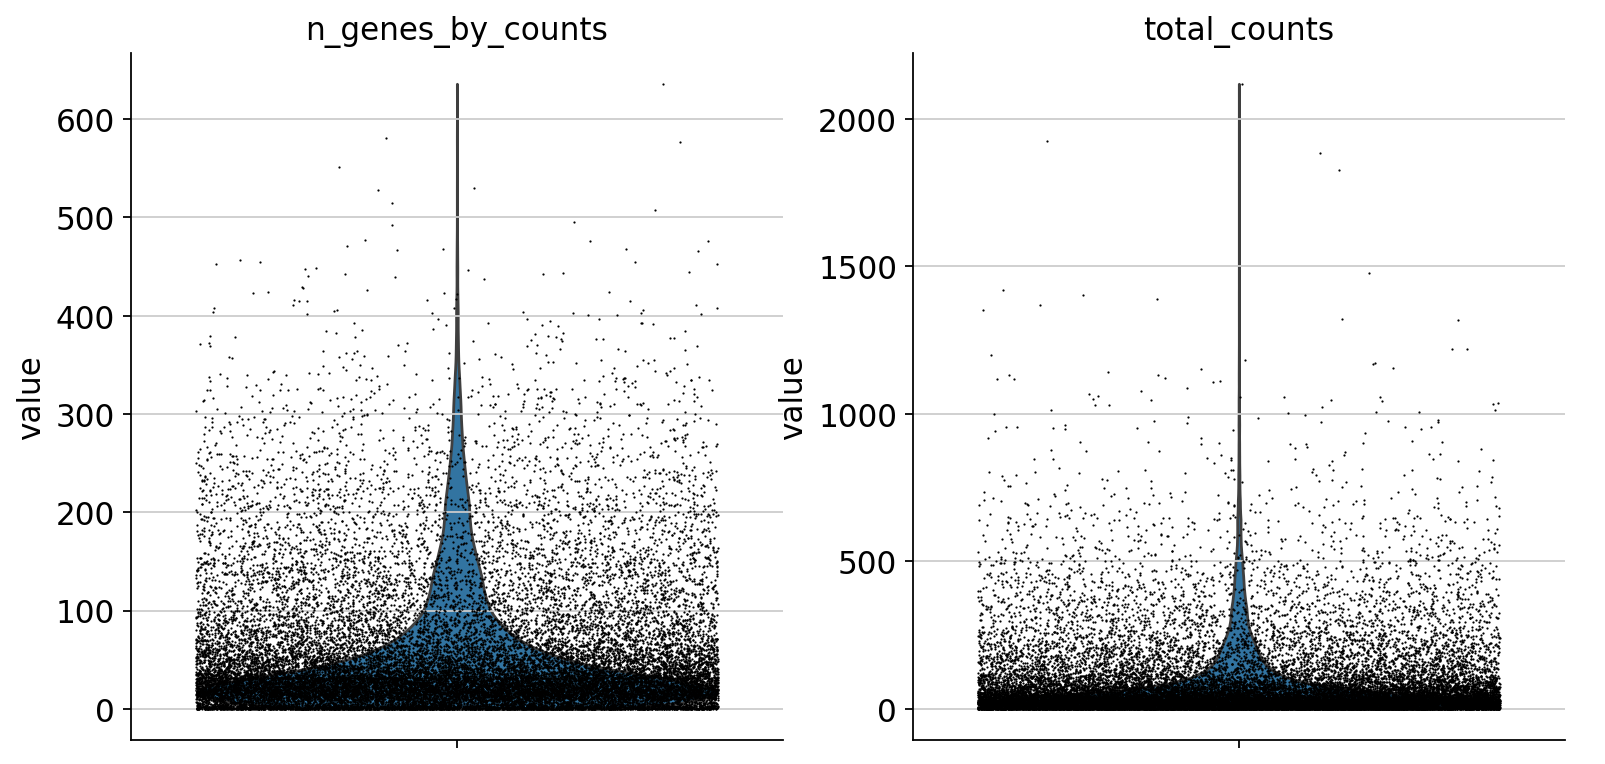

In [9]:
# Calculate QC metrics and add them directly to adata.obs
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Let's inspect the new columns added to metadata
print("New QC columns added:", adata.obs.columns.tolist())

# Visualize the distribution of genes and total counts per cell
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'],
             jitter=0.4, multi_panel=True, color='#1f77b4')

### ✂️ Step 5: Filtering Cells and Genes

Based on the violin plots, bacterial cells capture significantly fewer transcripts than eukaryotic cells. We will apply conservative thresholds suited for microSPLiT data:
- **Filter cells (Lower bound):** Keep cells with at least 15 genes detected to remove empty droplets.
- **Filter cells (Upper bound):** Remove cells with more than 400 genes to eliminate potential doublets.
- **Filter genes:** Keep genes expressed in at least 3 cells to remove background sequencing noise.

In [10]:
# 1. Filter cells based on minimum and maximum gene counts
sc.pp.filter_cells(adata, min_genes=15)
sc.pp.filter_cells(adata, max_genes=400)

# 2. Filter genes expressed in too few cells
sc.pp.filter_genes(adata, min_cells=3)

# Print the new dimensions of our cleaned dataset
print(f"✨ Dataset shape after QC filtering: {adata.shape}")

filtered out 6276 cells that have less than 15 genes expressed
filtered out 64 cells that have more than 400 genes expressed
filtered out 292 genes that are detected in less than 3 cells
✨ Dataset shape after QC filtering: (19106, 3477)


### 💾 Step 6: Saving the Quality-Controlled Dataset

After successfully filtering out low-quality cells and noisy genes, we save the cleaned `AnnData` object. This filtered dataset (`_filtered.h5ad`) will serve as the starting point for our next step: Normalization and Dimensionality Reduction.

In [11]:
# Save the filtered dataset to a new file
filtered_output_file = 'data/bacterial_microSPLiT_filtered.h5ad'
adata.write(filtered_output_file)

print(f"🎉 Notebook 01 Complete! Filtered dataset saved to: {filtered_output_file}")

🎉 Notebook 01 Complete! Filtered dataset saved to: data/bacterial_microSPLiT_filtered.h5ad
